### Runge–Kutta Method (4th Order)

The **4th Order Runge–Kutta Method (RK4)** is one of the most widely used techniques for solving ordinary differential equations, achieving high accuracy without requiring derivatives of \\(f\\):
$$
k_1 = f(x_n, y_n)
$$
$$
k_2 = f\left(x_n + \tfrac{h}{2},\, y_n + \tfrac{h}{2}k_1\right)
$$
$$
k_3 = f\left(x_n + \tfrac{h}{2},\, y_n + \tfrac{h}{2}k_2\right)
$$
$$
k_4 = f(x_n + h,\, y_n + h k_3)
$$
$$
y_{n+1} = y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)
$$

RK4 has **fourth-order accuracy** (\\(O(h^4)\\) local error), making it dramatically more accurate than the Euler or Improved Euler methods for the same step size.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x, y):
    return y - x**2 + 1

def y_exact(x):
    return (x + 1)**2 - 0.5 * np.exp(x)


In [3]:
def rk4_table(f, x0, y0, h, n_steps):
    print(f"{'n':>2} {'x':>10} {'y':>12} {'y_exact':>12} {'error':>12}")
    print("-" * 55)

    xs, ys = [x0], [y0]
    x, y = x0, y0

    print(f"{0:2d} {x:10.6f} {y:12.6f} {y_exact(x):12.6f} {abs(y - y_exact(x)):12.6e}")

    for n in range(1, n_steps + 1):
        k1 = f(x, y)
        k2 = f(x + h / 2, y + h / 2 * k1)
        k3 = f(x + h / 2, y + h / 2 * k2)
        k4 = f(x + h, y + h * k3)

        y = y + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        x = x + h
        xs.append(x)
        ys.append(y)
        print(f"{n:2d} {x:10.6f} {y:12.6f} {y_exact(x):12.6f} {abs(y - y_exact(x)):12.6e}")

    return np.array(xs), np.array(ys)


In [4]:
x0, y0 = 0, 0.5
h = 0.2
n_steps = 10

xs, ys = rk4_table(f, x0, y0, h, n_steps)
print(f"\ny({xs[-1]:.2f}) approx = {ys[-1]:.6f}, exact = {y_exact(xs[-1]):.6f}")


 n          x            y      y_exact        error
-------------------------------------------------------
 0   0.000000     0.500000     0.500000 0.000000e+00
 1   0.200000     0.829293     0.829299 5.287587e-06
 2   0.400000     1.214076     1.214088 1.144051e-05
 3   0.600000     1.648922     1.648941 1.858276e-05
 4   0.800000     2.127203     2.127230 2.685081e-05
 5   1.000000     2.640823     2.640859 3.639304e-05
 6   1.200000     3.179894     3.179942 4.736840e-05
 7   1.400000     3.732340     3.732400 5.994372e-05
 8   1.600000     4.283409     4.283484 7.428948e-05
 9   1.800000     4.815086     4.815176 9.057321e-05
10   2.000000     5.305363     5.305472 1.089498e-04

y(2.00) approx = 5.305363, exact = 5.305472


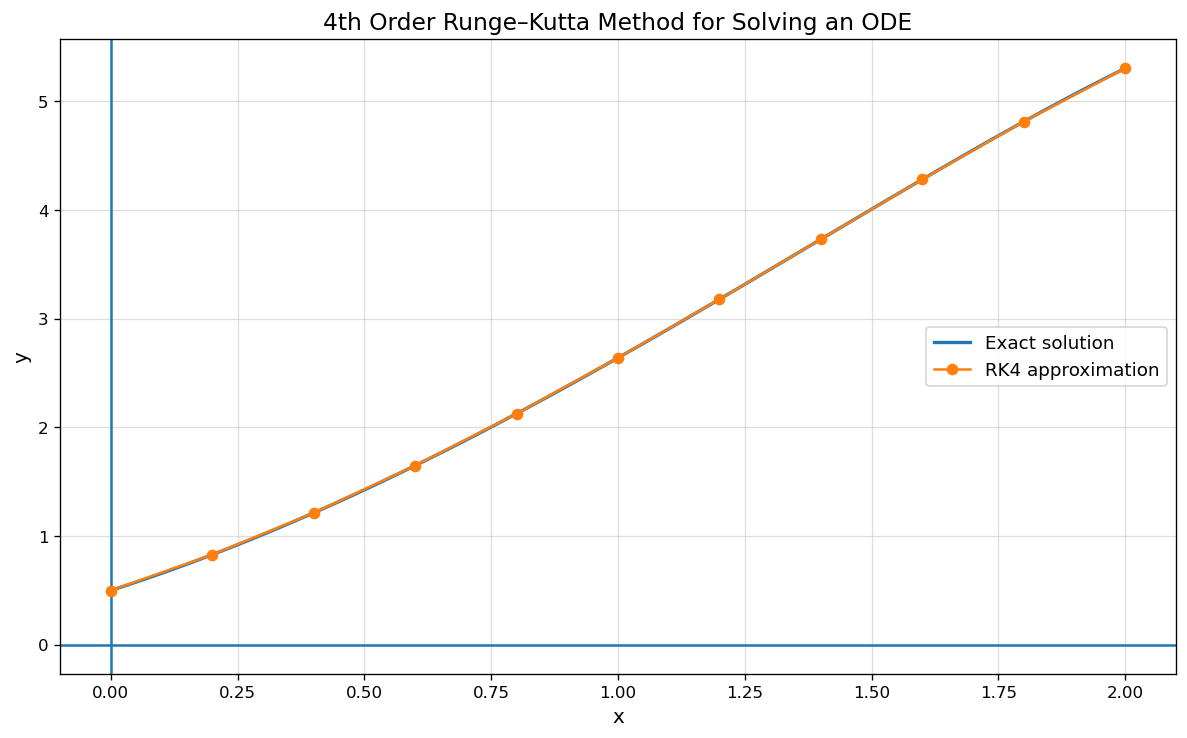

In [5]:
plt.figure(figsize=(12, 7), dpi=120)

# Axes lines (Desmos-style)
plt.axhline(0)
plt.axvline(0)

x_fine = np.linspace(x0, xs[-1], 500)
y_fine = y_exact(x_fine)

plt.plot(x_fine, y_fine, linewidth=2, label="Exact solution")
plt.plot(xs, ys, 'o-', markersize=6, label="RK4 approximation")

plt.grid(True, alpha=0.4)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("4th Order Runge\u2013Kutta Method for Solving an ODE", fontsize=14)

plt.legend(fontsize=11)
plt.show()
